In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# نسخة نظيفة من البيانات
df_clean = df.copy()

In [10]:
# 1. حذف الصفوف اللي معندهاش CustomerID (أساسي لـ RFM)
df_clean = df_clean.dropna(subset=['CustomerID'])


In [11]:
# 2. حذف الكميات السالبة (دي مرتجعات مش عمليات شراء فعلية)
df_clean = df_clean[df_clean['Quantity'] > 0]

In [12]:
# 3. حذف الأسعار اللي بصفر أو سالبة (أخطاء بيانات)
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [13]:
# 4. تحويل عمود التاريخ لصيغة datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


In [14]:
# 5. حساب الإيراد لكل صف (Revenue = Quantity × UnitPrice)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']


In [15]:
print("Shape after cleaning:", df_clean.shape)



Shape after cleaning: (397884, 9)


In [16]:
print("\nRemaining nulls:")
print(df_clean.isnull().sum())


Remaining nulls:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64


In [17]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
# تحديد "تاريخ اليوم" للتحليل = يوم بعد آخر عملية شراء في الداتا بيوم واحد
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)


Snapshot date: 2011-12-10 12:50:00


In [19]:
# حساب RFM لكل عميل
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Revenue': 'sum'                                           # Monetary
})


In [20]:

# تسمية الأعمدة
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("\nRFM Table Shape:", rfm.shape)


RFM Table Shape: (4338, 3)


In [21]:
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


In [22]:
# تقسيم كل مقياس لـ 5 فئات باستخدام qcut (Quantile-based)

# Recency: عكسي - الأقل هو الأفضل (labels من 5 لـ 1)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])


In [23]:
# Frequency: طردي - الأعلى هو الأفضل
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

In [24]:

# Monetary: طردي - الأعلى هو الأفضل
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

In [25]:
# دمج الـ 3 scores في RFM Score واحد
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [26]:
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112
12352.0,36,8,2506.04,3,5,5,355
12353.0,204,1,89.00,1,1,1,111
12354.0,232,1,1079.40,1,1,4,114
12355.0,214,1,459.40,1,1,2,112


In [27]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Potential Loyalist'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# عرض توزيع العملاء على الفئات
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)



Segment
Needs Attention       1061
Champions              962
Lost                   824
Loyal Customers        758
New Customers          319
Potential Loyalist     248
At Risk                166
Name: count, dtype: int64


In [28]:
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,Needs Attention
12347.0,2,7,4310.00,5,5,5,555,Champions
12348.0,75,4,1797.24,2,4,4,244,At Risk
12349.0,19,1,1757.55,4,1,4,414,New Customers
12350.0,310,1,334.40,1,1,2,112,Lost
12352.0,36,8,2506.04,3,5,5,355,Loyal Customers
12353.0,204,1,89.00,1,1,1,111,Lost
12354.0,232,1,1079.40,1,1,4,114,Needs Attention
12355.0,214,1,459.40,1,1,2,112,Lost


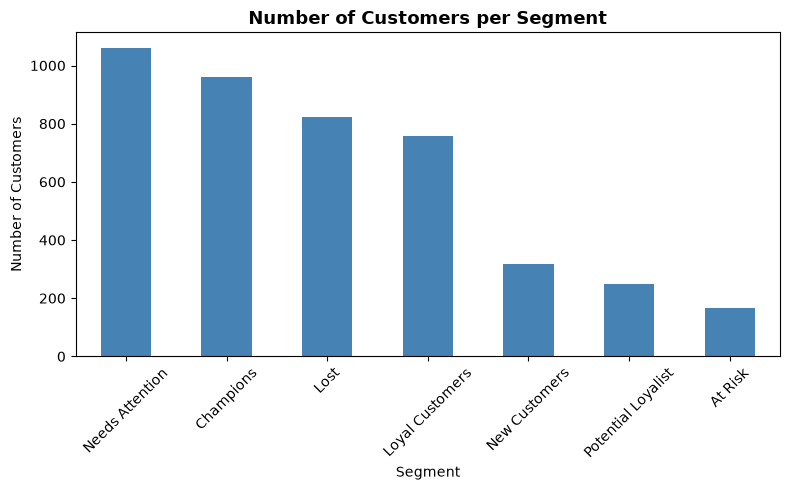

In [29]:
plt.figure(figsize=(8, 5))
segment_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Customers per Segment', fontsize=13, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

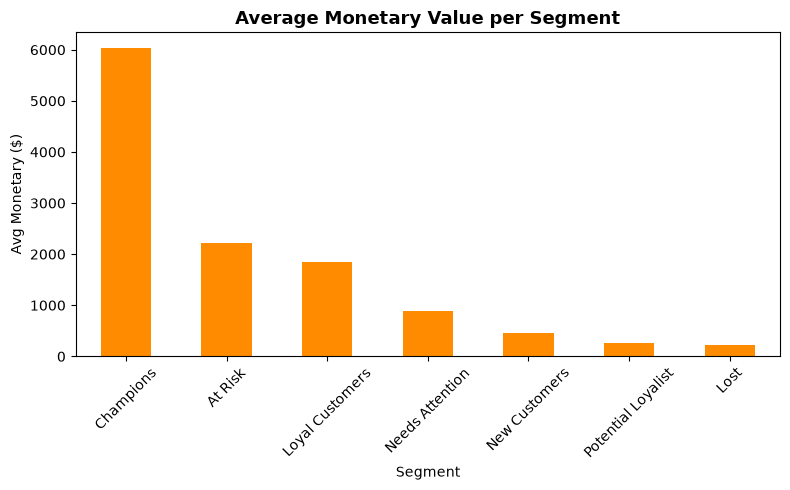

In [30]:
plt.figure(figsize=(8, 5))
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).plot(
    kind='bar', color='darkorange')
plt.title('Average Monetary Value per Segment', fontsize=13, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Avg Monetary ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_monetary_per_segment.png', dpi=150, bbox_inches='tight')
plt.show()

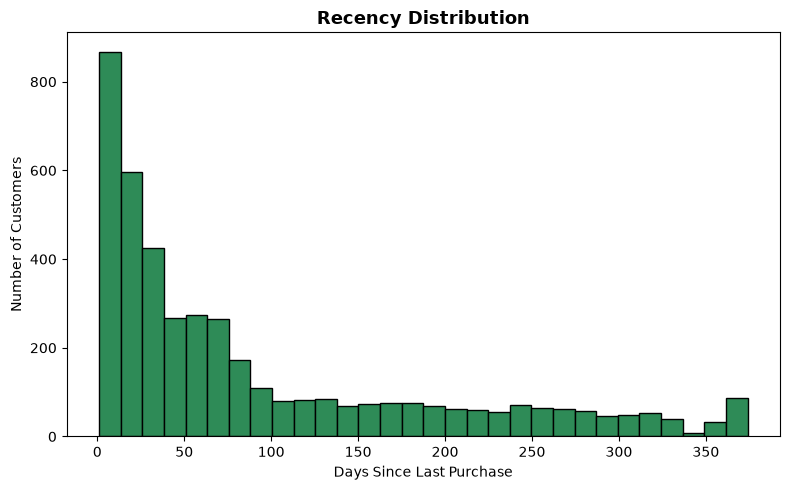

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(rfm['Recency'], bins=30, color='seagreen', edgecolor='black')
plt.title('Recency Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('recency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

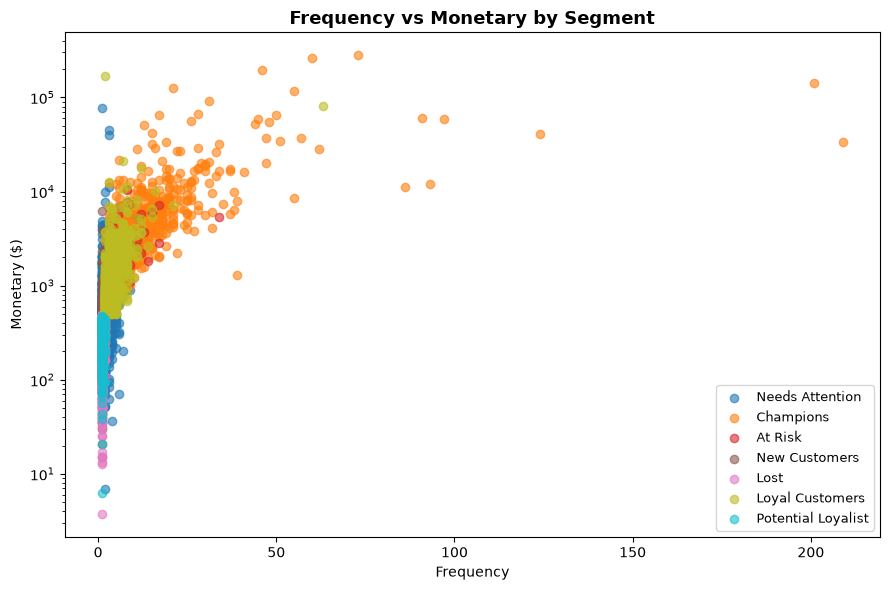

In [32]:
plt.figure(figsize=(9, 6))
segments = rfm['Segment'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(segments)))

for seg, color in zip(segments, colors):
    subset = rfm[rfm['Segment'] == seg]
    plt.scatter(subset['Frequency'], subset['Monetary'], 
                label=seg, alpha=0.6, color=color)

plt.title('Frequency vs Monetary by Segment', fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Monetary ($)')
plt.yscale('log')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('frequency_vs_monetary.png', dpi=150, bbox_inches='tight')
plt.show()

InvoiceDate
2010-12-31     572713.890
2011-01-31     569445.040
2011-02-28     447137.350
2011-03-31     595500.760
2011-04-30     469200.361
2011-05-31     678594.560
2011-06-30     661213.690
2011-07-31     600091.011
2011-08-31     645343.900
2011-09-30     952838.382
2011-10-31    1039318.790
2011-11-30    1161817.380
2011-12-31     518192.790
Freq: ME, Name: Revenue, dtype: float64


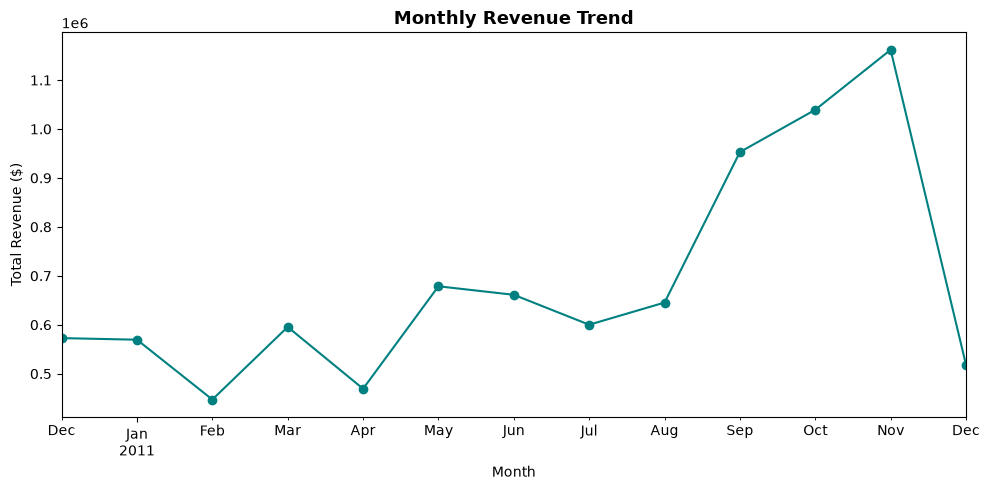

In [34]:
# تجميع الإيراد شهرياً
monthly_sales = df_clean.set_index('InvoiceDate').resample('ME')['Revenue'].sum()

print(monthly_sales)

plt.figure(figsize=(10, 5))
monthly_sales.plot(marker='o', color='teal')
plt.title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
from sklearn.linear_model import LinearRegression

# استبعاد آخر شهر لأنه بيانات غير مكتملة
monthly_sales_clean = monthly_sales[:-1]

# تجهيز البيانات للموديل: X = رقم الشهر بالترتيب، y = الإيراد
X = np.arange(len(monthly_sales_clean)).reshape(-1, 1)
y = monthly_sales_clean.values

# تدريب الموديل
model = LinearRegression()
model.fit(X, y)

# توقع 3 شهور جايين
future_months = np.arange(len(monthly_sales_clean), len(monthly_sales_clean) + 3).reshape(-1, 1)
predictions = model.predict(future_months)

print("Predicted revenue for next 3 months:")
for i, pred in enumerate(predictions, 1):
    print(f"Month +{i}: ${pred:,.2f}")

Predicted revenue for next 3 months:
Month +1: $1,037,466.78
Month +2: $1,089,471.73
Month +3: $1,141,476.68


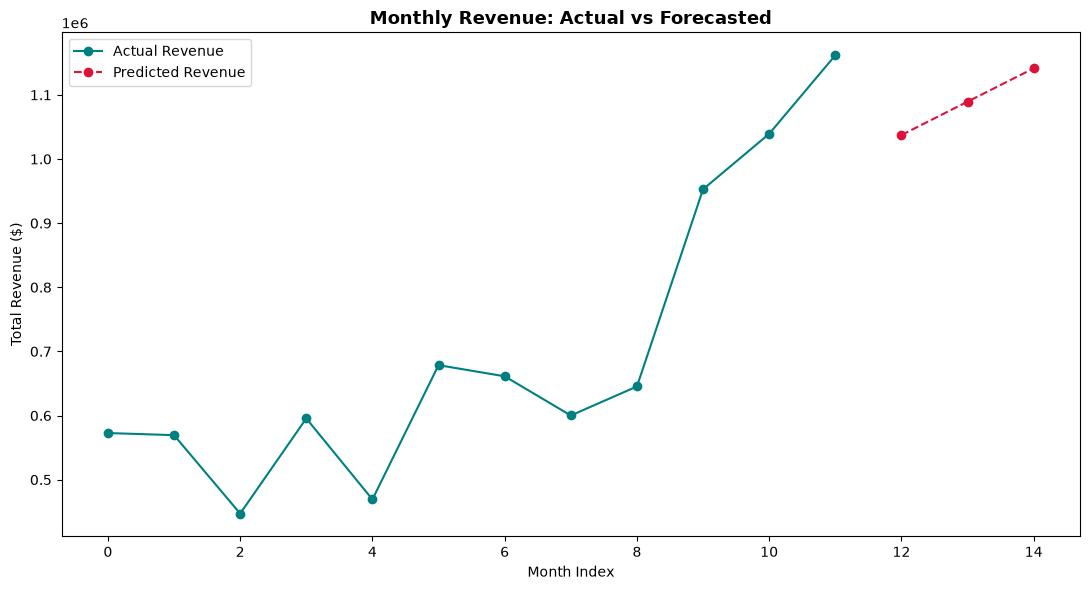

In [36]:
plt.figure(figsize=(11, 6))

# البيانات الحقيقية
plt.plot(range(len(monthly_sales_clean)), monthly_sales_clean.values, 
         marker='o', color='teal', label='Actual Revenue')

# البيانات المتوقعة
future_range = range(len(monthly_sales_clean), len(monthly_sales_clean) + 3)
plt.plot(future_range, predictions, 
         marker='o', color='crimson', linestyle='--', label='Predicted Revenue')

plt.title('Monthly Revenue: Actual vs Forecasted', fontsize=13, fontweight='bold')
plt.xlabel('Month Index')
plt.ylabel('Total Revenue ($)')
plt.legend()
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()